# PDF workflow validation — 120 recent HARTI bulletins

## tl;dr

- The existing five-step application workflow processed **120 of 120** randomly selected recent PDFs successfully.
- It stored **26,893** staging observations with **zero row-level validity failures** and **zero exact duplicate rows**.
- The cohort contains **53 repeated analytical grains**, including **48 revised values** across publications; a source-version policy is needed before canonical release.
- All documents matched the same labelled market/date grid strategy. This validates that template family, but does not yet test the fallback parsers against scanned or unrelated PDFs.


## Context & Methods

This is the reproducible companion to the stakeholder report. The cohort contains 120 archived HARTI publications dated 1 April–22 August 2026, randomly selected after excluding documents that already had a successful PDF-processing run. Every PDF was processed through `retrieve_pdf → parse_pdf → extract_data → validate_data → insert_data`.

### Key Assumptions

- Analytical price is the midpoint of each published minimum/maximum range, in LKR per source unit.
- For a repeated source-date × item × market × unit grain, analysis prefers the publication closest to the source date; the database retains all original rows.
- Period change compares the median of the first 14 available Peliyagoda observations with the median of the last 14.
- Results describe the sampled bulletin data and do not establish causes for price changes.


## Data

Load the exact batch manifest, analysis extract, local SQLite database, and auditable SQL check.

In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "foundry").is_dir() and (candidate / "package.json").is_file():
            return candidate
    raise RuntimeError("Repository root not found")


REPO_ROOT = find_repo_root()
REPORT_DIR = REPO_ROOT / "reports" / "pdf-workflow-validation-2026-08-22"
DB_PATH = REPO_ROOT / "data" / "runtime" / "local-validation.sqlite"

batch = json.loads((REPORT_DIR / "batch-results.json").read_text())
analysis = json.loads((REPORT_DIR / "analysis-output.json").read_text())
summary = analysis["summary"]

print(f"Batch: {analysis['batch_id']}")
print(f"Database: {DB_PATH}")
print(f"Cohort: {len(batch['documents'])} documents")


Batch: pdf-workflow-validation-2026-08-22
Database: data/runtime/local-validation.sqlite
Cohort: 120 documents


### 1. Reconcile persisted observations

In [2]:
connection = sqlite3.connect(DB_PATH)
connection.execute("CREATE TEMP TABLE validation_batch_artifact (artifact_id TEXT PRIMARY KEY)")
connection.executemany(
    "INSERT INTO validation_batch_artifact (artifact_id) VALUES (?)",
    [(document["artifact_id"],) for document in batch["documents"] if document["artifact_id"]],
)

quality_sql = (REPORT_DIR / "analysis.sql").read_text()
quality = pd.read_sql_query(quality_sql, connection)
quality


,stored_observations,invalid_observations,source_date_differs_from_publication,unique_source_dates,unique_item_labels,unique_markets
0,26893,0,5521,132,44,10


In [3]:
assert quality.loc[0, "stored_observations"] == summary["stored_observations"]
assert quality.loc[0, "invalid_observations"] == 0
assert quality.loc[0, "source_date_differs_from_publication"] == summary["prior_day_rows"]
assert summary["succeeded_documents"] == summary["selected_documents"] == 120
print("Database reconciliation passed.")


Database reconciliation passed.


### 2. Check repeated analytical grains

In [4]:
duplicate_sql = """
WITH grouped AS (
  SELECT observation.source_date,
         observation.source_item_label AS item,
         observation.source_market_label AS market,
         observation.source_unit AS unit,
         COUNT(*) AS rows,
         COUNT(DISTINCT printf('%d|%d', observation.min_value_minor, observation.max_value_minor)) AS value_versions
  FROM staging_observation AS observation
  JOIN validation_batch_artifact AS selected USING (artifact_id)
  GROUP BY observation.source_date, observation.source_item_label,
           observation.source_market_label, observation.source_unit
  HAVING COUNT(*) > 1
)
SELECT COUNT(*) AS repeated_groups,
       SUM(CASE WHEN value_versions > 1 THEN 1 ELSE 0 END) AS revised_value_groups
FROM grouped
"""
duplicates = pd.read_sql_query(duplicate_sql, connection)
assert duplicates.loc[0, "repeated_groups"] == summary["duplicate_analytical_grain_groups"]
assert duplicates.loc[0, "revised_value_groups"] == summary["conflicting_duplicate_groups"]
duplicates


,repeated_groups,revised_value_groups
0,53,48


## Results

### 3. Workflow depth by publication month

,month,documents,success_rate,observations,median_observations_per_pdf,min_observations_per_pdf,max_observations_per_pdf
0,2026-04,23,1,5119,227.0,96,250
1,2026-05,25,1,5863,241.0,171,252
2,2026-06,27,1,5776,220.0,131,248
3,2026-07,26,1,5742,221.5,168,250
4,2026-08,19,1,4393,229.0,218,248


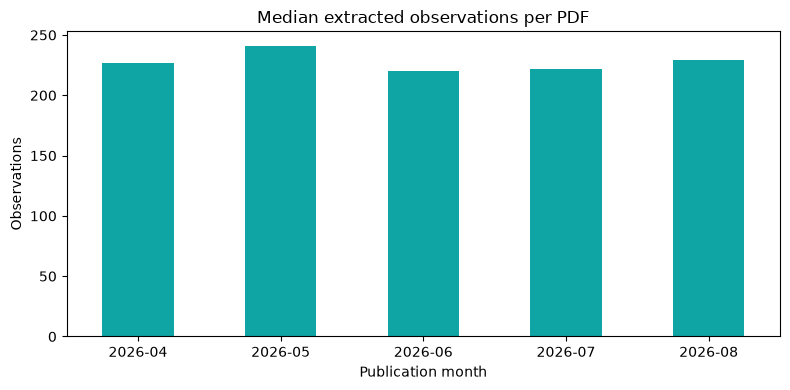

In [5]:
monthly = pd.DataFrame(analysis["monthly_quality"])
display(monthly[["month", "documents", "success_rate", "observations", "median_observations_per_pdf", "min_observations_per_pdf", "max_observations_per_pdf"]])

ax = monthly.plot.bar(
    x="month", y="median_observations_per_pdf", legend=False,
    color="#0ea5a4", figsize=(8, 4), title="Median extracted observations per PDF"
)
ax.set_xlabel("Publication month")
ax.set_ylabel("Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4. Selected Peliyagoda price series

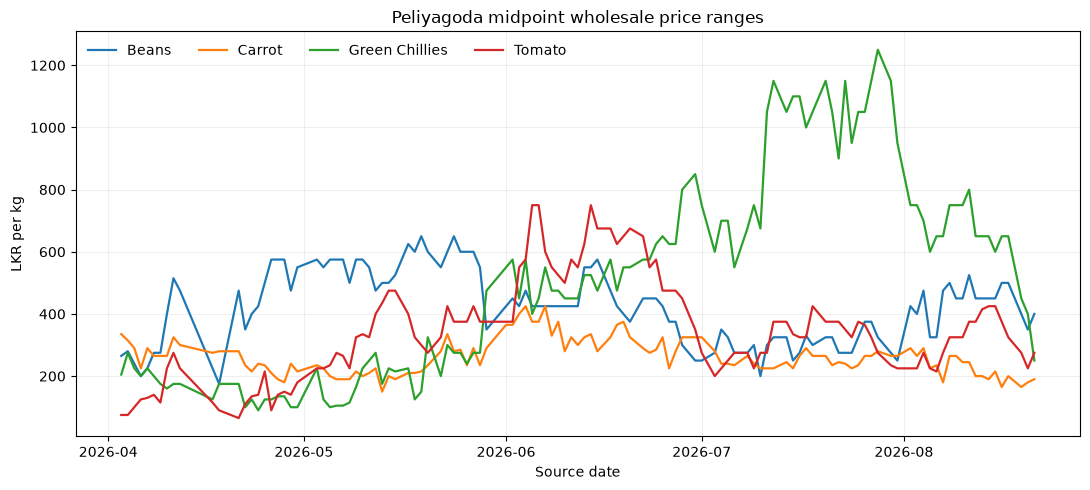

In [6]:
trend = pd.DataFrame(analysis["price_trend"])
trend["date"] = pd.to_datetime(trend["date"])
fig, ax = plt.subplots(figsize=(11, 5))
for item, rows in trend.groupby("item"):
    ax.plot(rows["date"], rows["midpoint_lkr"], label=item, linewidth=1.6)
ax.set_title("Peliyagoda midpoint wholesale price ranges")
ax.set_xlabel("Source date")
ax.set_ylabel("LKR per kg")
ax.legend(ncol=4, frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 5. Price level and volatility

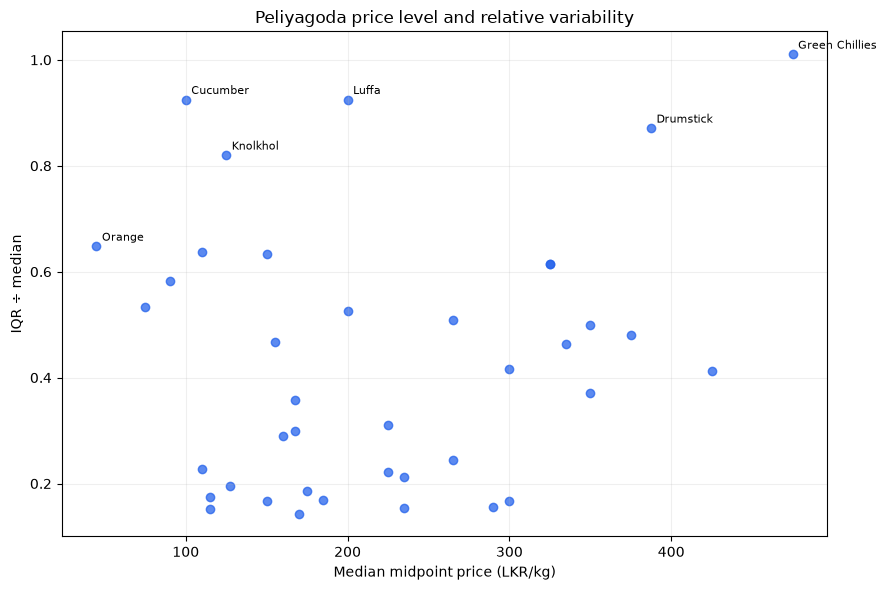

In [7]:
volatility = pd.DataFrame(analysis["volatility"])
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(volatility["median_midpoint_lkr"], volatility["relative_iqr"], alpha=0.75, color="#2563eb")
for row in volatility.nlargest(6, "relative_iqr").itertuples():
    ax.annotate(row.item, (row.median_midpoint_lkr, row.relative_iqr), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_title("Peliyagoda price level and relative variability")
ax.set_xlabel("Median midpoint price (LKR/kg)")
ax.set_ylabel("IQR ÷ median")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Takeaways

1. The workflow is operationally reliable for this labelled HARTI template family: 120/120 documents completed and every one passed all five steps.
2. Parser confidence alone is not a completeness score. Confidence was 1.0 for every PDF while extracted depth ranged from 96 to 252 rows.
3. Staging contains all 26,893 observations as `unmapped`; canonical item/market mappings remain a prerequisite for production price releases.
4. Price movements are broad but uneven. In Peliyagoda, Green Chillies and Tomato rose sharply between the defined early/late windows, while Carrot and Drumstick fell.
5. Version-aware deduplication should precede downstream reporting because revised previous-day market values appear across nearby publications.


In [8]:
connection.close()
print('Notebook checks completed successfully.')

Notebook checks completed successfully.
